In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df= df.iloc[:,2:]

In [17]:
df.sample(5)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
53,2,"Faunthorpe, Mrs. Lizzie (Elizabeth Anne Wilkin...",female,29.0,1,0,2926,26.0000,NaN,S
220,3,"Sunderland, Mr. Victor Francis",male,16.0,0,0,SOTON/OQ 392089,8.0500,NaN,S
680,3,"Peters, Miss. Katie",female,NaN,0,0,330935,8.1375,NaN,Q
151,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,C2,S
21,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S


train test split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train , X_test, y_train ,y_test =train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape , X_test.shape

KeyError: "['Purchased'] not found in axis"

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler.mean_

In [11]:
X_train_scaled = pd.DataFrame(X_train_scaled ,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled ,columns=X_test.columns)

In [12]:
np.round(X_train.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,38.0,69807.0
std,10.0,34641.0
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [13]:
np.round(X_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,1.0
max,2.0,2.0


In [14]:
df = pd.read_csv('titanic.csv')

In [26]:
#-----------maxabsscaler

In [27]:
from sklearn.preprocessing import MaxAbsScaler

In [28]:
df = pd.DataFrame({
    'Age': [18, 22, 25, 30, 35, 40, 45, 50],
    'Salary': [20000, 30000, 45000, 60000, 80000, 100000, 120000, 150000]
})

print("Original Data")
print(df)


Original Data
   Age  Salary
0   18   20000
1   22   30000
2   25   45000
3   30   60000
4   35   80000
5   40  100000
6   45  120000
7   50  150000


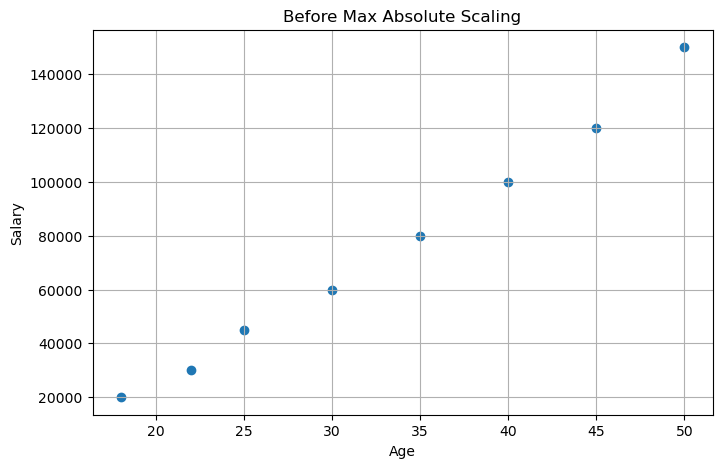

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Salary'])
plt.title("Before Max Absolute Scaling")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

In [30]:
scaler = MaxAbsScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print("\nScaled Data")
print(scaled_df)


Scaled Data
    Age    Salary
0  0.36  0.133333
1  0.44  0.200000
2  0.50  0.300000
3  0.60  0.400000
4  0.70  0.533333
5  0.80  0.666667
6  0.90  0.800000
7  1.00  1.000000


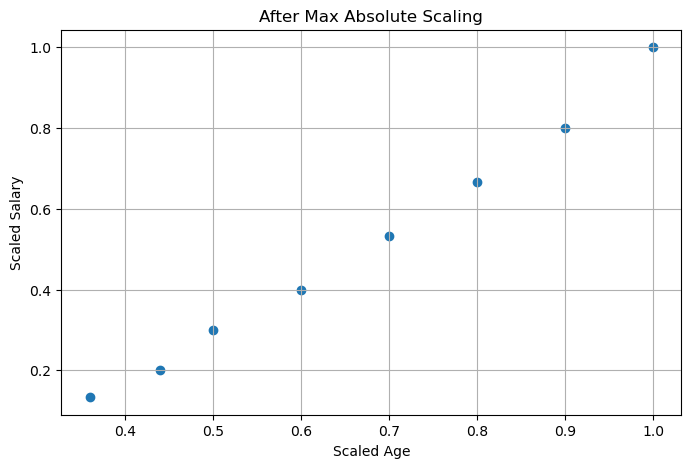

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(scaled_df['Age'], scaled_df['Salary'])
plt.title("After Max Absolute Scaling")
plt.xlabel("Scaled Age")
plt.ylabel("Scaled Salary")
plt.grid(True)
plt.show()

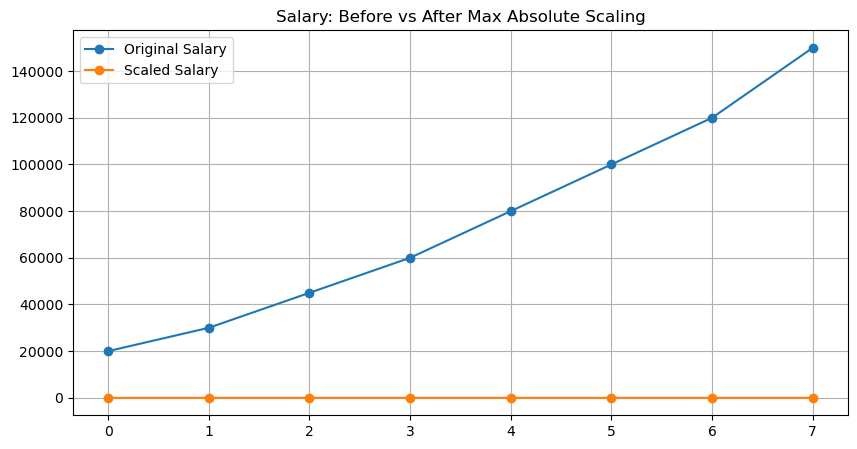

In [31]:
plt.figure(figsize=(10,5))

plt.plot(df['Salary'], label='Original Salary', marker='o')
plt.plot(scaled_df['Salary'], label='Scaled Salary', marker='o')

plt.title("Salary: Before vs After Max Absolute Scaling")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
#---------robust scaling

In [33]:
df = pd.DataFrame({
    'Age': [18, 22, 25, 28, 30, 32, 35, 40, 45, 100],
    'Salary': [25000, 30000, 35000, 40000, 45000,
               50000, 55000, 60000, 65000, 500000]
})

print("Original Data")
print(df)

Original Data
   Age  Salary
0   18   25000
1   22   30000
2   25   35000
3   28   40000
4   30   45000
5   32   50000
6   35   55000
7   40   60000
8   45   65000
9  100  500000


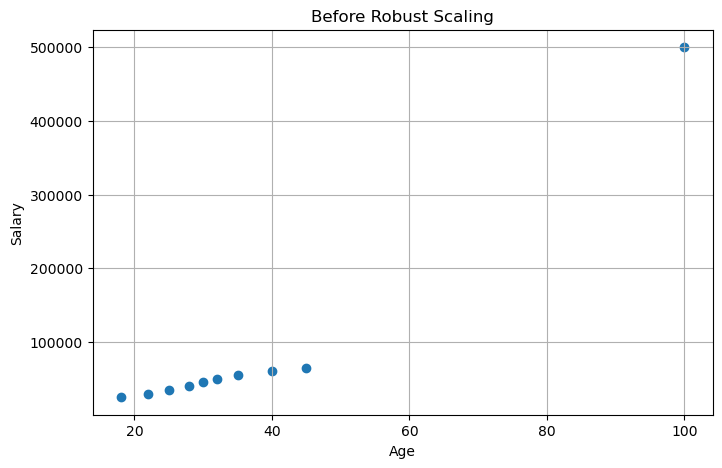

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Salary'])
plt.title("Before Robust Scaling")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)
plt.show()


In [36]:
# Step 3: Apply Robust Scaling
# -----------------------------
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print("\nScaled Data")
print(scaled_df)


Scaled Data
        Age     Salary
0 -1.000000  -1.000000
1 -0.692308  -0.777778
2 -0.461538  -0.555556
3 -0.230769  -0.333333
4 -0.076923  -0.111111
5  0.076923   0.111111
6  0.307692   0.333333
7  0.692308   0.555556
8  1.076923   0.777778
9  5.307692  20.111111


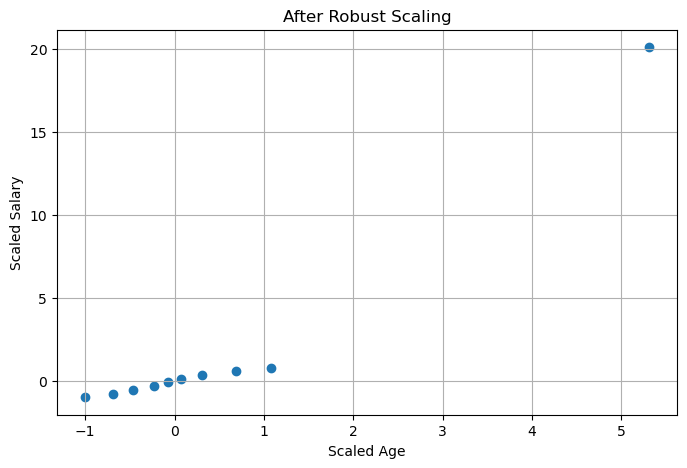

In [37]:
# Step 4: After Scaling Graph
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(scaled_df['Age'], scaled_df['Salary'])
plt.title("After Robust Scaling")
plt.xlabel("Scaled Age")
plt.ylabel("Scaled Salary")
plt.grid(True)
plt.show()

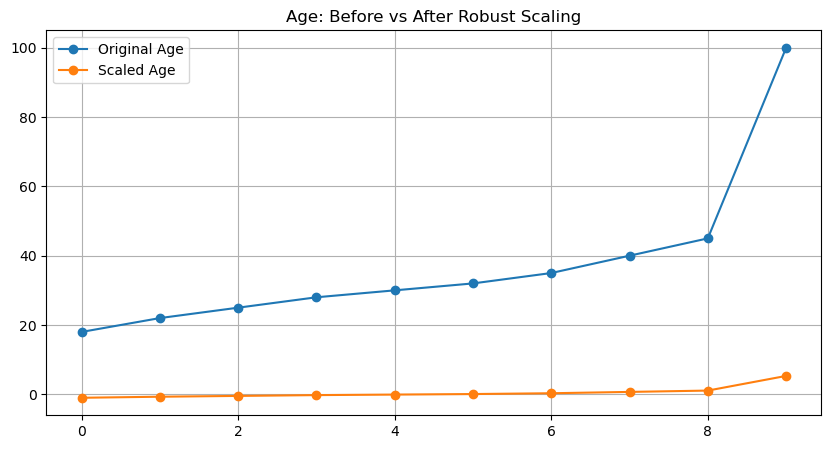

In [38]:
plt.figure(figsize=(10,5))

plt.plot(df['Age'], marker='o', label='Original Age')
plt.plot(scaled_df['Age'], marker='o', label='Scaled Age')

plt.title("Age: Before vs After Robust Scaling")
plt.legend()
plt.grid(True)
plt.show()

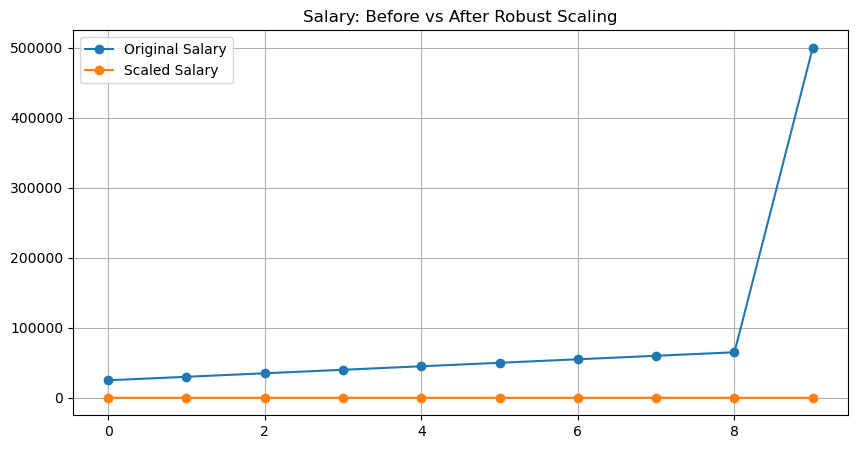

In [39]:
plt.figure(figsize=(10,5))

plt.plot(df['Salary'], marker='o', label='Original Salary')
plt.plot(scaled_df['Salary'], marker='o', label='Scaled Salary')

plt.title("Salary: Before vs After Robust Scaling")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
#----mean normalization

In [41]:
df = pd.DataFrame({
    'Age': [18, 22, 25, 30, 35, 40, 45, 50],
    'Salary': [20000, 30000, 45000, 60000, 80000, 100000, 120000, 150000]
})

print("Original Data")
print(df)

Original Data
   Age  Salary
0   18   20000
1   22   30000
2   25   45000
3   30   60000
4   35   80000
5   40  100000
6   45  120000
7   50  150000


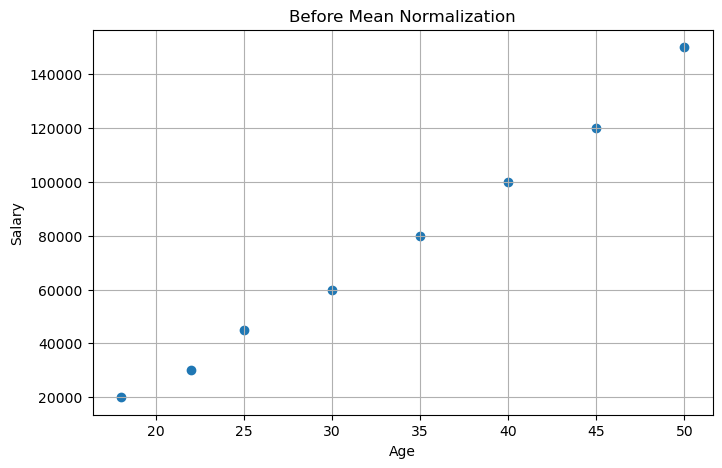

In [42]:
# Step 2: Before Scaling Graph
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Salary'])
plt.title("Before Mean Normalization")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

In [43]:
# Step 3: Mean Normalization
# -----------------------------
scaled_df = (df - df.mean()) / (df.max() - df.min())

print("\nMean Normalized Data")
print(scaled_df)


Mean Normalized Data
        Age    Salary
0 -0.472656 -0.427885
1 -0.347656 -0.350962
2 -0.253906 -0.235577
3 -0.097656 -0.120192
4  0.058594  0.033654
5  0.214844  0.187500
6  0.371094  0.341346
7  0.527344  0.572115


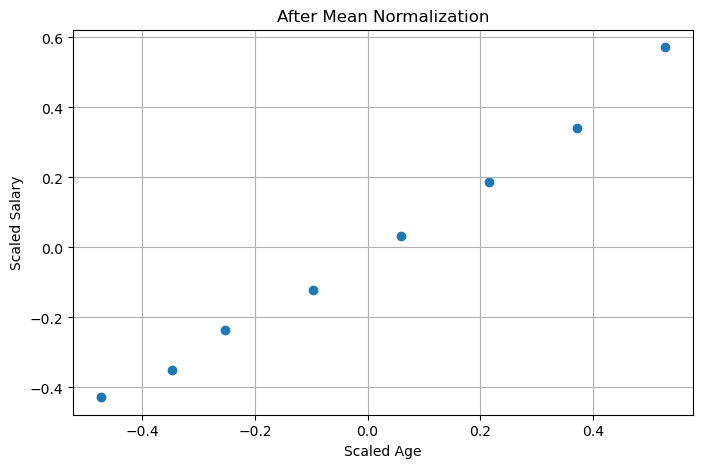

In [44]:
# Step 4: After Scaling Graph
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(scaled_df['Age'], scaled_df['Salary'])
plt.title("After Mean Normalization")
plt.xlabel("Scaled Age")
plt.ylabel("Scaled Salary")
plt.grid(True)
plt.show()

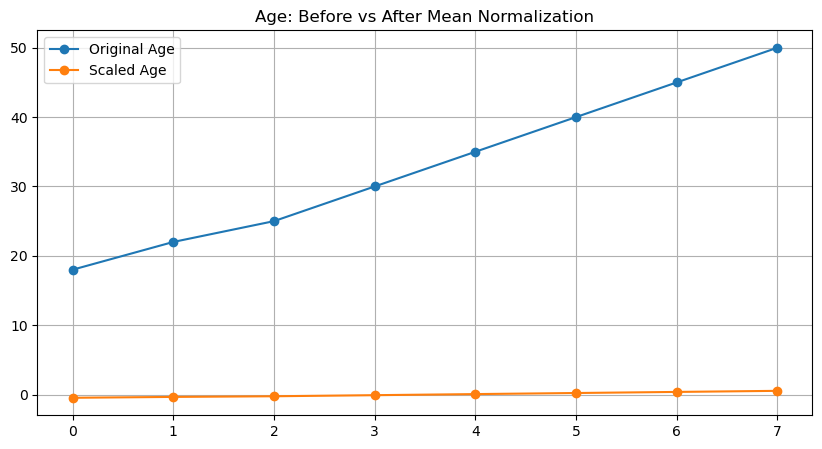

In [45]:
plt.figure(figsize=(10,5))

plt.plot(df['Age'], marker='o', label='Original Age')
plt.plot(scaled_df['Age'], marker='o', label='Scaled Age')

plt.title("Age: Before vs After Mean Normalization")
plt.legend()
plt.grid(True)
plt.show()

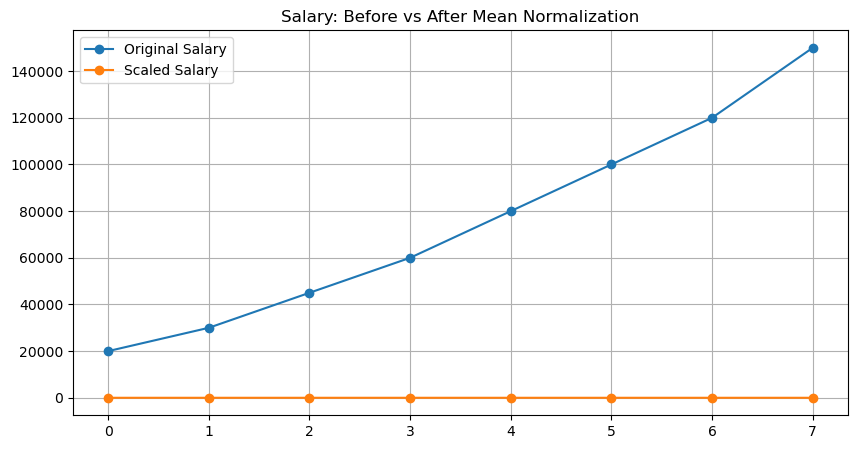

In [46]:
plt.figure(figsize=(10,5))

plt.plot(df['Salary'], marker='o', label='Original Salary')
plt.plot(scaled_df['Salary'], marker='o', label='Scaled Salary')

plt.title("Salary: Before vs After Mean Normalization")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
#label encoding

In [48]:
from sklearn.preprocessing import OrdinalEncoder

In [49]:
import seaborn as sns

In [101]:
iris = sns.load_dataset('iris')

In [102]:
iris.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
25,5.0,3.0,1.6,0.2,setosa
136,6.3,3.4,5.6,2.4,virginica
26,5.0,3.4,1.6,0.4,setosa
28,5.2,3.4,1.4,0.2,setosa
103,6.3,2.9,5.6,1.8,virginica
112,6.8,3.0,5.5,2.1,virginica
126,6.2,2.8,4.8,1.8,virginica
47,4.6,3.2,1.4,0.2,setosa
143,6.8,3.2,5.9,2.3,virginica
135,7.7,3.0,6.1,2.3,virginica


In [55]:
encoder = OrdinalEncoder(categories=[[
     'setosa',
    'versicolor',
    'virginica'
]])

In [60]:
iris['species_encoded']=encoder.fit_transform(iris[['species']])
print(iris.sample(5))

     sepal_length  sepal_width  petal_length  petal_width     species  \
69            5.6          2.5           3.9          1.1  versicolor   
66            5.6          3.0           4.5          1.5  versicolor   
23            5.1          3.3           1.7          0.5      setosa   
113           5.7          2.5           5.0          2.0   virginica   
131           7.9          3.8           6.4          2.0   virginica   

     species_encoded  
69               1.0  
66               1.0  
23               0.0  
113              2.0  
131              2.0  


In [61]:
print(iris[['species','species_encoded']].drop_duplicates())

        species  species_encoded
0        setosa              0.0
50   versicolor              1.0
100   virginica              2.0


In [62]:
#another way for target columns

In [77]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

In [66]:
iris['species']=le.fit_transform(iris['species'])

In [67]:
print(iris.sample(5))

     sepal_length  sepal_width  petal_length  petal_width  species  \
47            4.6          3.2           1.4          0.2        0   
105           7.6          3.0           6.6          2.1        2   
127           6.1          3.0           4.9          1.8        2   
102           7.1          3.0           5.9          2.1        2   
22            4.6          3.6           1.0          0.2        0   

     species_encoded  
47               0.0  
105              2.0  
127              2.0  
102              2.0  
22               0.0  


In [103]:
iris['species'] = iris['species'].map({
    'setosa': 0,
    'versicolor': 1,
    'virginica':2
})

In [104]:
print(iris['species'].unique())

[0 1 2]


In [99]:
#iris.head()
print(iris['species'].unique())

[nan]


In [69]:
tips = sns.load_dataset('tips')

In [71]:
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size
228,13.28,2.72,Male,No,Sat,Dinner,2
133,12.26,2.00,Female,No,Thur,Lunch,2
22,15.77,2.23,Female,No,Sat,Dinner,2
221,13.42,3.48,Female,Yes,Fri,Lunch,2
66,16.45,2.47,Female,No,Sat,Dinner,2


In [72]:
encoder = OrdinalEncoder(categories=[[
    'Male',
    'Female',]])
    

In [74]:
tips['sex_encoded']=encoder.fit_transform(tips[['sex']])
print(tips.sample(5))

     total_bill   tip     sex smoker   day    time  size  sex_encoded
10        10.27  1.71    Male     No   Sun  Dinner     2          0.0
2         21.01  3.50    Male     No   Sun  Dinner     3          0.0
74        14.73  2.20  Female     No   Sat  Dinner     2          1.0
217       11.59  1.50    Male    Yes   Sat  Dinner     2          0.0
122       14.26  2.50    Male     No  Thur   Lunch     2          0.0


In [85]:
print(tips[['sex','sex_encoded']].drop_duplicates())

      sex  sex_encoded
0  Female          1.0
1    Male          0.0


In [86]:
tips['sex_encoded'] = tips['sex'].map({
    'Male': 0,
    'Female': 1
})

In [87]:
print(tips[['sex', 'sex_encoded']].drop_duplicates())

      sex sex_encoded
0  Female           1
1    Male           0


In [88]:
tips['sex'] = tips['sex'].map({
    'Male': 0,
    'Female': 1
})

In [89]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size,sex_encoded
0,16.99,1.01,1,No,Sun,Dinner,2,1
1,10.34,1.66,0,No,Sun,Dinner,3,0
2,21.01,3.50,0,No,Sun,Dinner,3,0
3,23.68,3.31,0,No,Sun,Dinner,2,0
4,24.59,3.61,1,No,Sun,Dinner,4,1


In [105]:
import seaborn as sns

iris = sns.load_dataset('iris')

In [106]:
iris['species'] = iris['species'].map({
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
})

In [109]:
iris.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
82,5.8,2.7,3.9,1.2,1
102,7.1,3.0,5.9,2.1,2
75,6.6,3.0,4.4,1.4,1
91,6.1,3.0,4.6,1.4,1
18,5.7,3.8,1.7,0.3,0


In [110]:
#---------ONE HOT ENCODING

In [111]:
cars= pd.read_csv('cars.csv')

In [114]:
cars.head(2)

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,Emission_Norm,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
0,Tata,Nano Genx,Xt,"Rs. 2,92,667",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tata,Nano Genx,Xe,"Rs. 2,36,447",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1276 entries, 0 to 1275
Columns: 140 entries, Make to Electric_Range
dtypes: float64(6), object(134)
memory usage: 1.4+ MB


In [118]:
import seaborn as sns
import pandas as pd

tips = sns.load_dataset('tips')

tips.sample(5)


,total_bill,tip,sex,smoker,day,time,size
198,13.00,2.00,Female,Yes,Thur,Lunch,2
206,26.59,3.41,Male,Yes,Sat,Dinner,3
81,16.66,3.40,Male,No,Thur,Lunch,2
77,27.20,4.00,Male,No,Thur,Lunch,4
149,7.51,2.00,Male,No,Thur,Lunch,2


In [123]:
pd.get_dummies(tips, columns=['sex'], dtype=int, drop_first=True).head()

,total_bill,tip,smoker,day,time,size,sex_Female
0,16.99,1.01,No,Sun,Dinner,2,1
1,10.34,1.66,No,Sun,Dinner,3,0
2,21.01,3.50,No,Sun,Dinner,3,0
3,23.68,3.31,No,Sun,Dinner,2,0
4,24.59,3.61,No,Sun,Dinner,4,1


In [124]:
#for multiple columns

In [127]:
encoded= pd.get_dummies(tips,columns=[
    'sex','smoker'],dtype=int,drop_first=True
                       )

In [128]:
print(encoded.head())

   total_bill   tip  day    time  size  sex_Female  smoker_No
0       16.99  1.01  Sun  Dinner     2           1          1
1       10.34  1.66  Sun  Dinner     3           0          1
2       21.01  3.50  Sun  Dinner     3           0          1
3       23.68  3.31  Sun  Dinner     2           0          1
4       24.59  3.61  Sun  Dinner     4           1          1


In [129]:
import pandas as pd

df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
    'Brand': ['Apple', 'Samsung', 'Apple', 'Oppo', 'Samsung']
})

encoded = pd.get_dummies(
    df,
    columns=['Color', 'Brand'],
    dtype=int
)

print(encoded)

   Color_Blue  Color_Green  Color_Red  Brand_Apple  Brand_Oppo  Brand_Samsung
0           0            0          1            1           0              0
1           1            0          0            0           0              1
2           0            1          0            1           0              0
3           0            0          1            0           1              0
4           1            0          0            0           0              1


In [130]:
en = pd.get_dummies(
    df,
    columns=['Color', 'Brand'],
    dtype=int,drop_first=True
)
print(en)

   Color_Green  Color_Red  Brand_Oppo  Brand_Samsung
0            0          1           0              0
1            0          0           0              1
2            1          0           0              0
3            0          1           1              0
4            0          0           0              1


In [131]:
import seaborn as sns 

In [132]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [134]:
encoded= pd.get_dummies(iris,
                         columns=['species'],dtype=int,drop_first=True)

In [139]:
print(encoded.head(5))

   sepal_length  sepal_width  petal_length  petal_width  species_1  species_2
0           5.1          3.5           1.4          0.2          0          0
1           4.9          3.0           1.4          0.2          0          0
2           4.7          3.2           1.3          0.2          0          0
3           4.6          3.1           1.5          0.2          0          0
4           5.0          3.6           1.4          0.2          0          0


In [140]:
en = pd.get_dummies(tips,
                    columns=['sex','smoker','day','time'],dtype=int)
en.head()
                    

,total_bill,tip,size,sex_Male,sex_Female,smoker_Yes,smoker_No,day_Thur,day_Fri,day_Sat,day_Sun,time_Lunch,time_Dinner
0,16.99,1.01,2,0,1,0,1,0,0,0,1,0,1
1,10.34,1.66,3,1,0,0,1,0,0,0,1,0,1
2,21.01,3.50,3,1,0,0,1,0,0,0,1,0,1
3,23.68,3.31,2,1,0,0,1,0,0,0,1,0,1
4,24.59,3.61,4,0,1,0,1,0,0,0,1,0,1


In [141]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [142]:
numeric_cols = ['total_bill', 'tip', 'size']

categorical_cols = ['sex', 'smoker', 'day', 'time']

In [143]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

In [144]:
X_transformed = preprocessor.fit_transform(tips)

In [146]:
X_transformed.shape

(244, 13)

In [161]:
df = sns.load_dataset('titanic')

In [162]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [163]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler 
from sklearn.tree import DecisionTreeClassifier

In [192]:
t = df.drop(columns=['class','who','adult_male','deck','embark_town','alive','alone'])
t.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C


In [193]:
#step1... 
X_train , X_test, y_train,y_test= train_test_split(t.drop(columns=['survived']),
                                                   t['survived'],
                                                   test_size=0.2,
                                                   random_state=42)
#is me hum ne training data me survived kko chor ke sare column de dea or
#testing me survived de dea

In [194]:
X_train.head(2)

,pclass,sex,age,sibsp,parch,fare,embarked
331,1,male,45.5,0,0,28.5,S
733,2,male,23.0,0,0,13.0,S


In [170]:
y_train.sample(5)

249    0
238    0
506    1
663    0
705    0
Name: survived, dtype: int64

In [172]:
t.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [173]:
#to fill the missing value write in age

In [179]:
si_age= SimpleImputer()
si_embarked = SimpleImputer(strategy = 'most_frequent')

X_train_age = si_age.fit_transform(X_train[['age']])
X_train_embarked = si_embarked.fit_transform(X_train[['embarked']])

X_test_age = si_age.transform(X_test[['age']])
X_test_embarked = si_embarked.fit_transform(X_test[['embarked']])

In [184]:
#one hot encoding on sex and embarked

In [187]:
si_sex= OneHotEncoder(sparse_output=False , handle_unknown= 'ignore')
oe_embarked= OneHotEncoder(sparse_output=False , handle_unknown= 'ignore')

X_train_sex = si_sex.fit_transform(X_train[['sex']])
X_train_embarked = oe_embarked.fit_transform(X_train[['embarked']])

X_test_age = si_age.transform(X_test[['age']])
X_test_embarked = oe_embarked.fit_transform(X_test[['embarked']])

In [190]:
X_train_sex

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [1., 0.],
       [0., 1.]])

In [191]:
#through pipeline

In [227]:
#impute transformer
t1 = ColumnTransformer([
    ('impute_age', SimpleImputer(strategy='mean'), [2]),
    ('impute_embarked', SimpleImputer(strategy='most_frequent'), [6])
], remainder='passthrough')

In [201]:
#one hot encoding 
t2 = ColumnTransformer([
 ('oe_embarked',OneHotEncoder(sparse_output=False , handle_unknown= 'ignore'),[1,6])
], remainder='passthrough')

In [203]:
#scaling
t3 = ColumnTransformer([
    ('scale',MinMaxScaler(),slice(0,8))
])

In [235]:
#feature scaling 
t5 = SelectKBest(score_func=chi2 ,k=8)

In [236]:
t6=DecisionTreeClassifier() #train the model

In [239]:
#create pipeline

In [241]:
pipe = Pipeline([
    ('t1',t1),
    ('t2',t2),
    ('t3',t3),
    ('t5',t5),
    ('t6',t6),
])

In [244]:
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(t1,t2,t3,t5,t6)

In [248]:
#train 
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_age', SimpleImputer(),
                                                  [2]),
                                                 ('impute_embarked',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [6])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe_embarked',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6])])),
                ('columntransformer-3',
                 ColumnTransformer(transformers=[('scale', MinMaxScaler(),
                                                  slice(0, 8, None))])),
                ('selectkbest',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x000002092E4CBD80>)),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [238]:
#----------------------my practice 

In [212]:
df = sns.load_dataset('penguins')
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [213]:
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


In [214]:
p = df.drop(columns = ['species','flipper_length_mm','body_mass_g'])

In [215]:
p.head(3)

,island,bill_length_mm,bill_depth_mm,sex
0,Torgersen,39.1,18.7,Male
1,Torgersen,39.5,17.4,Female
2,Torgersen,40.3,18.0,Female


In [216]:
p.isnull().sum()

island             0
bill_length_mm     2
bill_depth_mm      2
sex               11
dtype: int64

In [221]:
#missing values 
p1 = ColumnTransformer([
   ('impute_bill_depth_mm',SimpleImputer(strategy='mean'),[2]),
    ('impute_sex',SimpleImputer(strategy='most_frequent'),[3]),
], remainder='passthrough')


In [223]:
p_transformed = p1.fit_transform(p)

In [226]:
p_transformed

array([[18.7, 'Male', 'Torgersen', 39.1],
       [17.4, 'Female', 'Torgersen', 39.5],
       [18.0, 'Female', 'Torgersen', 40.3],
       ...,
       [15.7, 'Male', 'Biscoe', 50.4],
       [14.8, 'Female', 'Biscoe', 45.2],
       [16.1, 'Male', 'Biscoe', 49.9]], dtype=object)

In [230]:
p2= ColumnTransformer([
    ('oe_sex',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[3])
],remainder='passthrough')

In [231]:
#scaling
p3 = ColumnTransformer([
    ('scale',MinMaxScaler(),slice(0,8))
])

In [234]:
from sklearn.feature_selection import SelectKBest, chi2
p5 = SelectKBest(score_func=chi2 ,k=8)

In [237]:
p6 = DecisionTreeClassifier()

In [249]:
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(p1,p2,p3,p5,p6)

In [251]:
#------------function transformer

In [253]:
import pandas as pd
import seaborn as sns
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt 

from sklearn.model_selection import cross_val_score 
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

In [335]:
df = sns.load_dataset('titanic')
df = df[['age', 'fare', 'survived',]]

,pclass,sex,sibsp,parch,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,1,0,S,Third,man,True,NaN,Southampton,no,False
1,1,female,1,0,C,First,woman,False,C,Cherbourg,yes,False
2,3,female,0,0,S,Third,woman,False,NaN,Southampton,yes,True


In [336]:
df = df[['age', 'fare', 'survived',]]

In [337]:
df.head(3)

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1


In [277]:
df['age'].fillna(df['age'].mean(),inplace=True)

C:\Users\me\AppData\Local\Temp\ipykernel_11240\1492264711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [278]:
df.isnull().sum()

age         0
fare        0
survived    0
dtype: int64

In [279]:
#extract x and y 
X= df.iloc[:,1:3]
y=df.iloc[:,0]

In [269]:
#train_test split
X_train , X_test, y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\me\AppData\Local\Temp\ipykernel_11240\2604880797.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['age'])


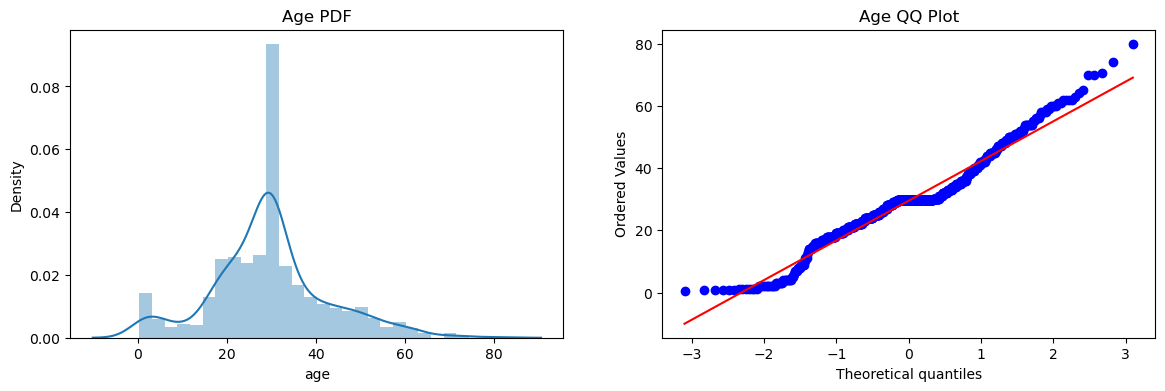

In [282]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['age'])
plt.title('Age PDF')


plt.subplot(122)
stats.probplot(X_train['age'],dist="norm",plot=plt)
plt.title('Age QQ Plot')
plt.show()

C:\Users\me\AppData\Local\Temp\ipykernel_11240\1907102631.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['fare'])


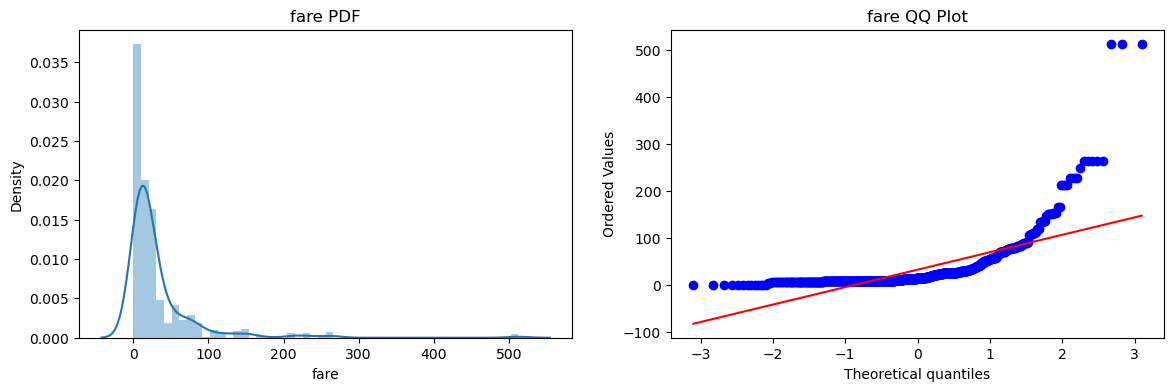

In [284]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['fare'])
plt.title('fare PDF')


plt.subplot(122)
stats.probplot(X_train['fare'],dist="norm",plot=plt)
plt.title('fare QQ Plot')
plt.show()

In [274]:
X_train.columns

Index(['fare', 'survived'], dtype='object')

In [280]:
X = df[['age', 'fare']]
y = df['survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [281]:
X_train['age']

331    45.500000
733    23.000000
382    32.000000
704    26.000000
813     6.000000
         ...    
106    21.000000
270    29.699118
860    41.000000
435    14.000000
102    21.000000
Name: age, Length: 712, dtype: float64

In [287]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [288]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred=clf.predict(X_test)
y_pred2=clf2.predict(X_test)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred2))

Accuracy LR 0.6480446927374302
Accuracy DT 0.659217877094972


In [290]:
trf= FunctionTransformer(func=np.log1p)

In [291]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [293]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred=clf.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6703910614525139


In [294]:
#power transformer

In [295]:
import pandas as pd
import seaborn as sns
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt 

from sklearn.model_selection import cross_val_score 
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer

In [298]:
df = pd.read_csv('concrete_data.csv')

In [299]:
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [300]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [303]:
df.shape

(1030, 9)

In [305]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [307]:
x=df.drop(columns=['concrete_compressive_strength'])
y=df.iloc[:,-1]

In [330]:
lr = LinearRegression()

lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.09733529909665473

In [313]:
X = df.drop('concrete_compressive_strength', axis=1)
y = df['concrete_compressive_strength']

In [314]:
print(X.shape)
print(y.shape)

(1030, 8)
(1030,)


In [319]:
lr = LinearRegression()

scores = cross_val_score(
    lr,
    X,
    y,
    scoring='r2'
)

#print(scores)
print(np.mean(scores))

0.46099404916628667


C:\Users\me\AppData\Local\Temp\ipykernel_11240\3281154984.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


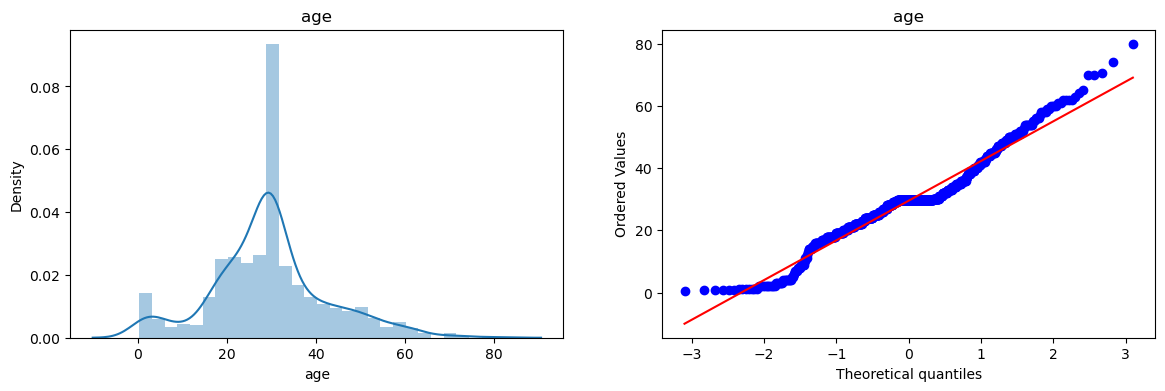

C:\Users\me\AppData\Local\Temp\ipykernel_11240\3281154984.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


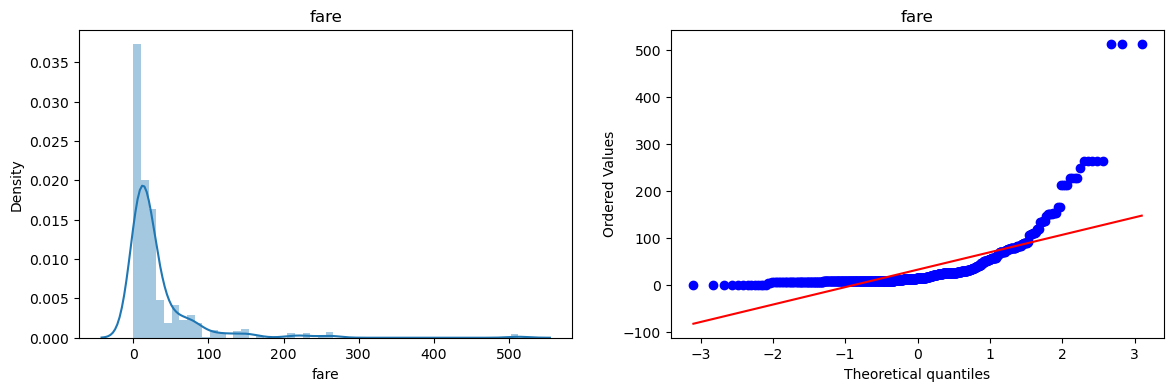

In [322]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)


    plt.subplot(122)
    stats.probplot(X_train[col],dist="norm",plot=plt)
    plt.title(col)
    plt.show()

In [323]:
#boxcoxplot

In [329]:
plt = PowerTransformer(method='box-cox')

X_train_transformed = plt.fit_transform(X_train+0.000001)
X_test_transformed = plt.transform(X_test+0.000001)

pd.DataFrame({
    'cols':X_train.columns,
    'box_cox_lambdas':plt.lambdas_})

,cols,box_cox_lambdas
0,age,0.848399
1,fare,0.232301


In [ ]:
#again apply algo

In [331]:
lr = LinearRegression()

lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)
r2_score(y_test,y_pred2)

0.1624398182976451

In [332]:
#binning and binarization

In [351]:
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [352]:
from sklearn.preprocessing import KBinsDiscretizer

In [364]:
df.dropna(inplace=True)

In [365]:
df.isnull().sum()

age         0
fare        0
survived    0
dtype: int64

In [355]:
X= df.iloc[:,1:]
y=df.iloc[:,0]

In [366]:
X_train , X_test, y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [367]:
clf = DecisionTreeClassifier()

In [358]:
y_train.head(2)

328    31.0
73     26.0
Name: age, dtype: float64

In [368]:
clf.fit(X_train,y_train)

y_pred=clf.predict(X_test)

In [369]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [371]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6373043818466353)

In [361]:
X = df[['age', 'fare']]
y = df['survived']

In [372]:
kb_age = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='kmeans'
)

kb_fare = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='kmeans'
)


In [375]:
trf = ColumnTransformer(
    [('first',kb_age,[0]),
    ('second',kb_fare,[1]),
    ])

In [377]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [379]:
trf.named_transformers_['first'].n_bins_

array([5])

In [382]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42      , 12.69636862, 27.02765256, 39.35418895, 54.21464646,
              80.        ])                                                   ],
      dtype=object)